Para esta notebook se usan los Datos Históricos de **Precipitación** de la **Estacion 4232 - Yacanto**

Fuente: https://snih.hidricosargentina.gob.ar

In [ ]:
# Importo librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Libreria que sirve para hacer el grid del plot con fechas más personalizable


## Carga de datos

In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/Precipitacion-Estacion4232.xlsx"

datos_precipitacion = pd.read_excel(url, header = 1)


In [ ]:
datos_precipitacion["Fecha y Hora"] = pd.to_datetime(datos_precipitacion["Fecha y Hora"],
                                       dayfirst = True)

datos_precipitacion = datos_precipitacion.rename(columns={"Precipitación [mm]": "Precipitación"})    # Acortamos el nombre para simplificar

datos_precipitacion.head()

,Fecha y Hora,Precipitación
0,1990-01-01 10:00:00,26.5
1,1990-01-02 10:00:00,0.0
2,1990-01-03 10:00:00,0.0
3,1990-01-04 10:00:00,0.0
4,1990-01-05 10:00:00,0.0


Chequeamos si hay datos de fechas repetidas

In [ ]:
datos_precipitacion["Fecha y Hora"].duplicated().sum()

np.int64(0)

Quitamos información de hora

In [ ]:
datos_precipitacion["Fecha y Hora"] = datos_precipitacion["Fecha y Hora"].dt.normalize()   # Cambia todos los horarios a medianoche
datos_precipitacion = datos_precipitacion.rename(columns={"Fecha y Hora": "Fecha"})        # Cambio el nombre a la columna
datos_precipitacion.head()

,Fecha,Precipitación
0,1990-01-01,26.5
1,1990-01-02,0.0
2,1990-01-03,0.0
3,1990-01-04,0.0
4,1990-01-05,0.0


Chequeamos qué fechas faltan en el dataset


In [ ]:
fechas_esperadas = pd.date_range(
                              start = datos_precipitacion["Fecha"].min(),
                              end = datos_precipitacion["Fecha"].max(),
                              freq = "D"
                          )

fechas_faltantes = fechas_esperadas.difference(datos_precipitacion["Fecha"])

print("Cantidad de días faltantes:", len(fechas_faltantes))
print(fechas_faltantes)

Cantidad de días faltantes: 519
DatetimeIndex(['1992-05-01', '1992-05-02', '1992-05-03', '1992-05-04',
               '1992-05-05', '1992-05-06', '1992-05-07', '1992-05-08',
               '1992-05-09', '1992-05-10',
               ...
               '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24',
               '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28',
               '2026-04-29', '2026-04-30'],
              dtype='datetime64[ns]', length=519, freq=None)


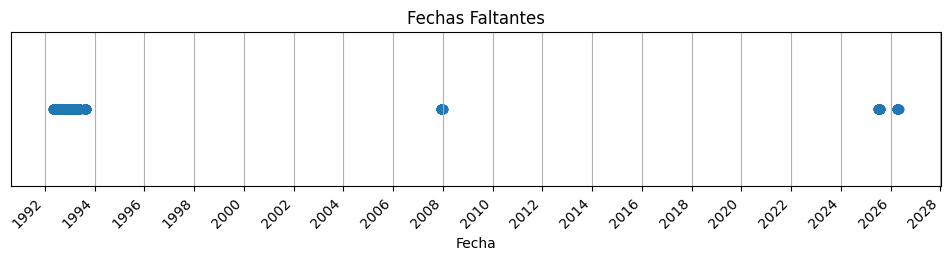

In [ ]:
plt.figure(figsize=(12, 2))

plt.scatter(
            fechas_faltantes,
            [1] * len(fechas_faltantes)
        )

plt.yticks([])
plt.xlabel("Fecha")
plt.title("Fechas Faltantes")
plt.grid()

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))        # Permite hacer el grid cada 5 años
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')                             # Pone los valores del eje x en 45º

plt.show()

Como hay una gran cantidad de fechas faltantes antes de 1994, decidimos eliminar esas filas del dataset

In [ ]:
datos_precipitacion = datos_precipitacion[datos_precipitacion["Fecha"] >= "1994-01-01"].reset_index(drop=True)
datos_precipitacion.head()

,Fecha,Precipitación
0,1994-01-01,0.0
1,1994-01-02,55.0
2,1994-01-03,0.0
3,1994-01-04,0.0
4,1994-01-05,0.0


De la lista de fechas esperadas elimino las anteriores a 1994

In [ ]:
fechas_esperadas = fechas_esperadas[fechas_esperadas >= "1994-01-01"]
fechas_esperadas

DatetimeIndex(['1994-01-01', '1994-01-02', '1994-01-03', '1994-01-04',
               '1994-01-05', '1994-01-06', '1994-01-07', '1994-01-08',
               '1994-01-09', '1994-01-10',
               ...
               '2026-05-22', '2026-05-23', '2026-05-24', '2026-05-25',
               '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29',
               '2026-05-30', '2026-05-31'],
              dtype='datetime64[ns]', length=11839, freq='D')

Calculo las nuevas fechas faltantes

In [ ]:
fechas_faltantes = fechas_esperadas.difference(datos_precipitacion["Fecha"])

faltantes_por_mes = (pd.Series(fechas_faltantes)
                    .groupby(fechas_faltantes.to_period("M")) # Agrupamos por mes las fechas faltantes
                    .size())

print(faltantes_por_mes)

2007-12    31
2025-07    31
2026-04    30
Freq: M, dtype: int64


Como faltan los datos de 3 meses completos, en esta notebook, decidimos rellenarlos con un promedio de los datos de cada día en el año anterior y posterior

In [ ]:
for fecha in fechas_faltantes:

    fecha_anterior = fecha - pd.DateOffset(years=1)  # Calcula cual es la fecha un año antes
    fecha_siguiente = fecha + pd.DateOffset(years=1) # Calcula cual es la fecha un año después

    valores = []

    # Año anterior
    fila_anterior = datos_precipitacion.loc[datos_precipitacion["Fecha"] == fecha_anterior, "Precipitación"]

    if not fila_anterior.empty:
        valores.append(fila_anterior.iloc[0])

    # Año siguiente
    fila_siguiente = datos_precipitacion.loc[datos_precipitacion["Fecha"] == fecha_siguiente, "Precipitación"]

    if not fila_siguiente.empty:
        valores.append(fila_siguiente.iloc[0])

    # Promedio
    if valores:
        nuevo_valor = np.mean(valores)
    else:
        nuevo_valor = np.nan

    # Crear nueva fila
    nueva_fila = pd.DataFrame({
        "Fecha": [fecha],
        "Precipitación": [nuevo_valor]
    })

    datos_precipitacion = pd.concat([datos_precipitacion, nueva_fila], ignore_index=True)

Reordenamos las filas según la fecha, porque las fechas se agregaron al final

In [ ]:
datos_precipitacion = datos_precipitacion.sort_values("Fecha").reset_index(drop=True)

Graficamos todos los datos

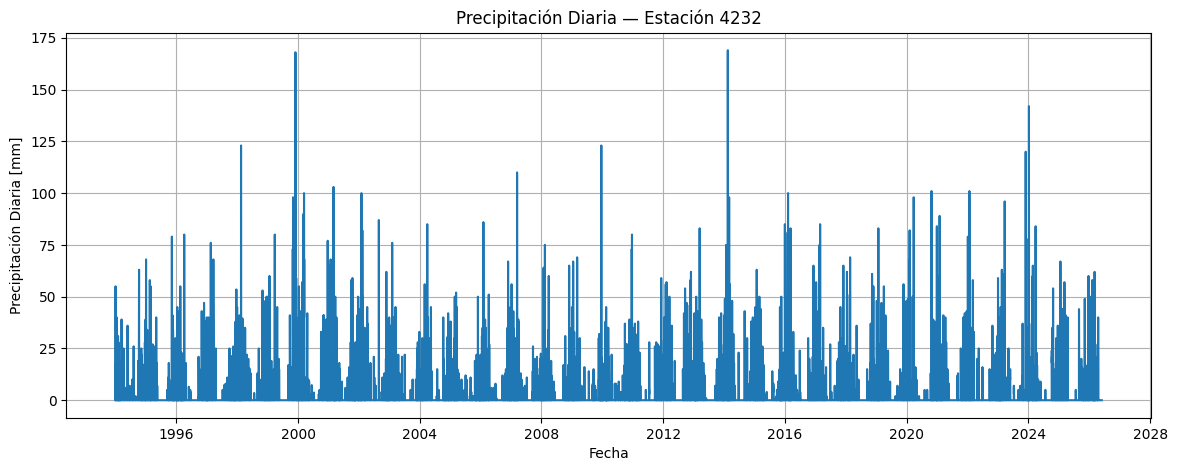

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(datos_precipitacion["Fecha"], datos_precipitacion["Precipitación"])

plt.xlabel("Fecha")
plt.ylabel("Precipitación Diaria [mm]")
plt.title("Precipitación Diaria — Estación 4232")
plt.grid()
plt.show()

# Transformaciones

In [ ]:
y = datos_precipitacion["Precipitación"]
x = datos_precipitacion["Fecha"]

Creamos función para graficar los datos originales y los transformados

In [ ]:
def plot_transformation(fecha, original, transformado, titulo):

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))

    axes[0].plot(fecha, original)
    axes[0].set_title("Serie Original")

    axes[1].plot(fecha, transformado)
    axes[1].set_title(titulo)

    plt.tight_layout()
    plt.show()

## Transformaciones de Escala

1) Transformación Logarítmica **Log(y)**

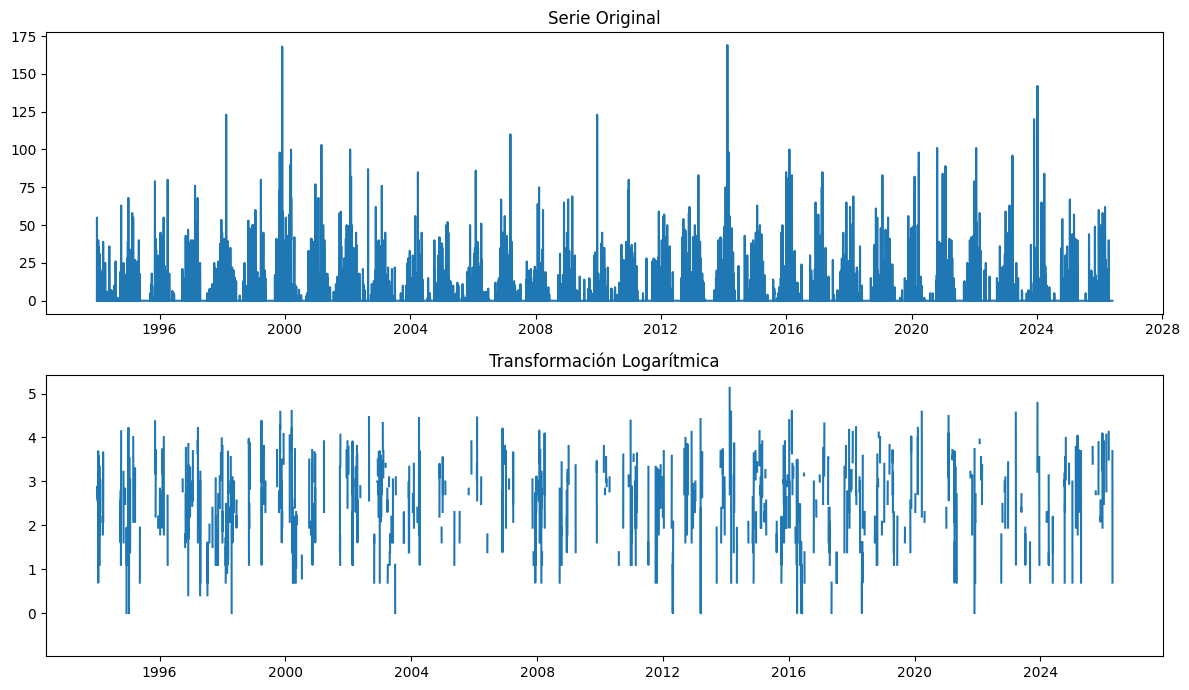

In [ ]:
y_log = np.log(y)

plot_transformation(x, y, y_log,"Transformación Logarítmica")

2) Transformación logarítmica con desplazamiento: **Log(1+y)**

Permite obtener valores de logaritmo cuando y = 0:

Log(0) = inf

Log(1 + 0) = 0

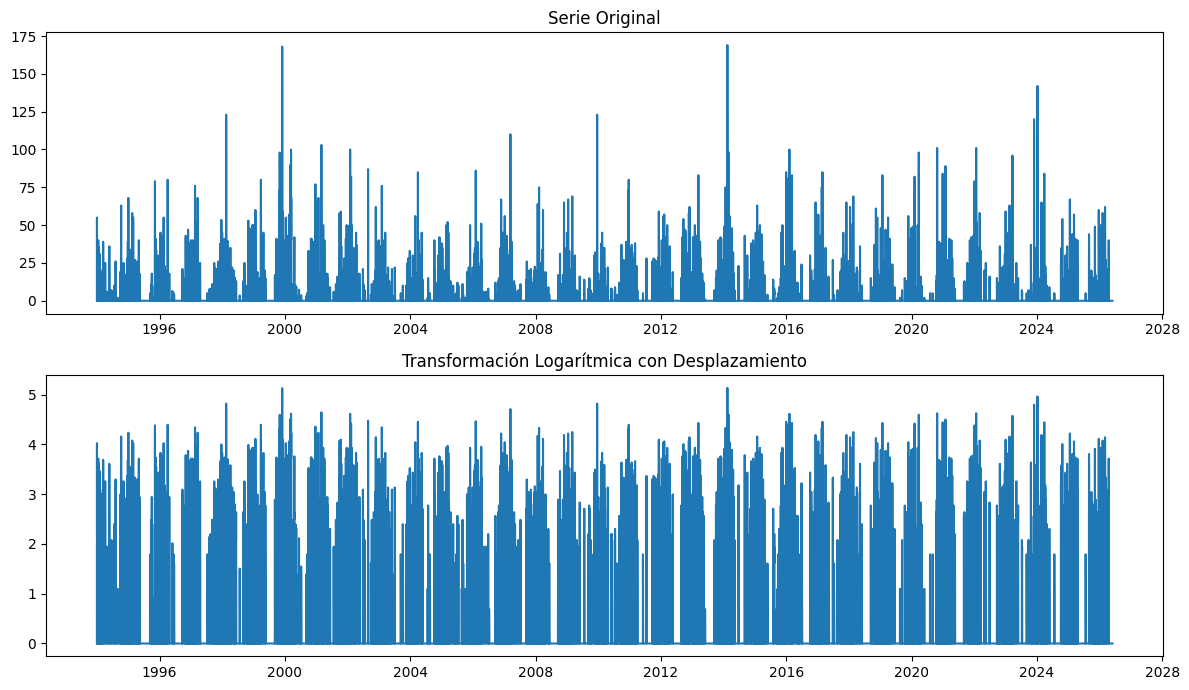

In [ ]:
y_log1p = np.log1p(y)

plot_transformation(x, y, y_log1p,"Transformación Logarítmica con Desplazamiento")

3) Raiz cuadrada $\sqrt(y)$

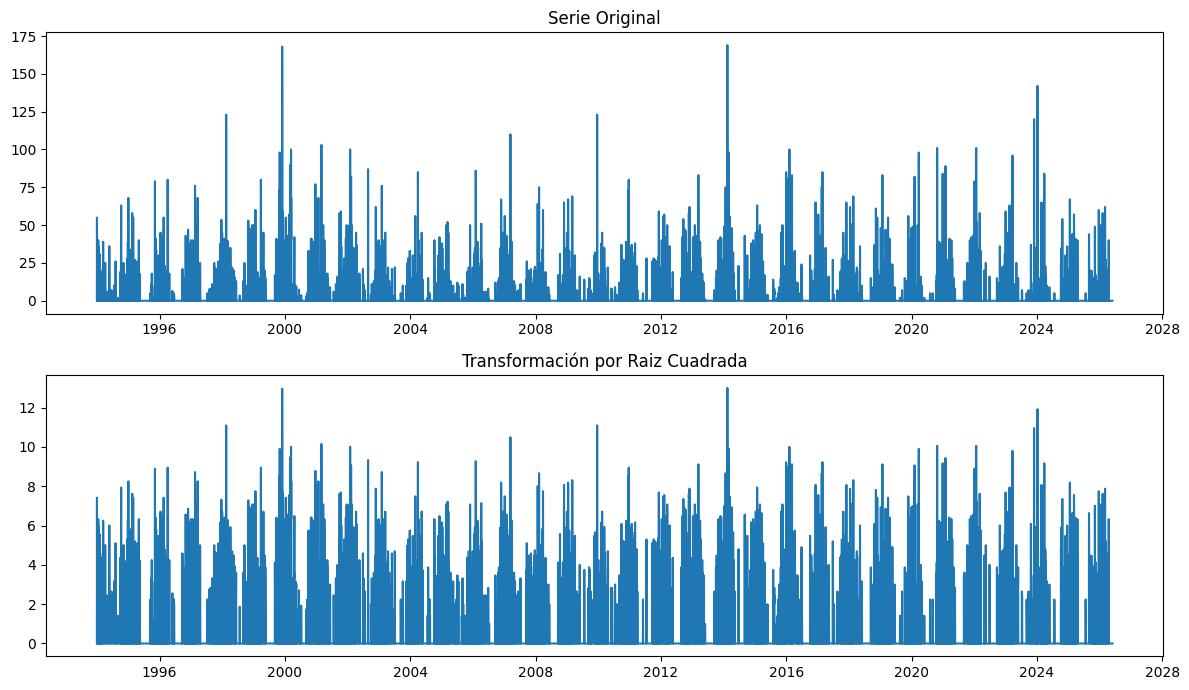

In [ ]:
y_sqrt = np.sqrt(y)

plot_transformation(x, y, np.sqrt(y), "Transformación por Raiz Cuadrada")

4) Transformación por Potencia $y^\lambda$

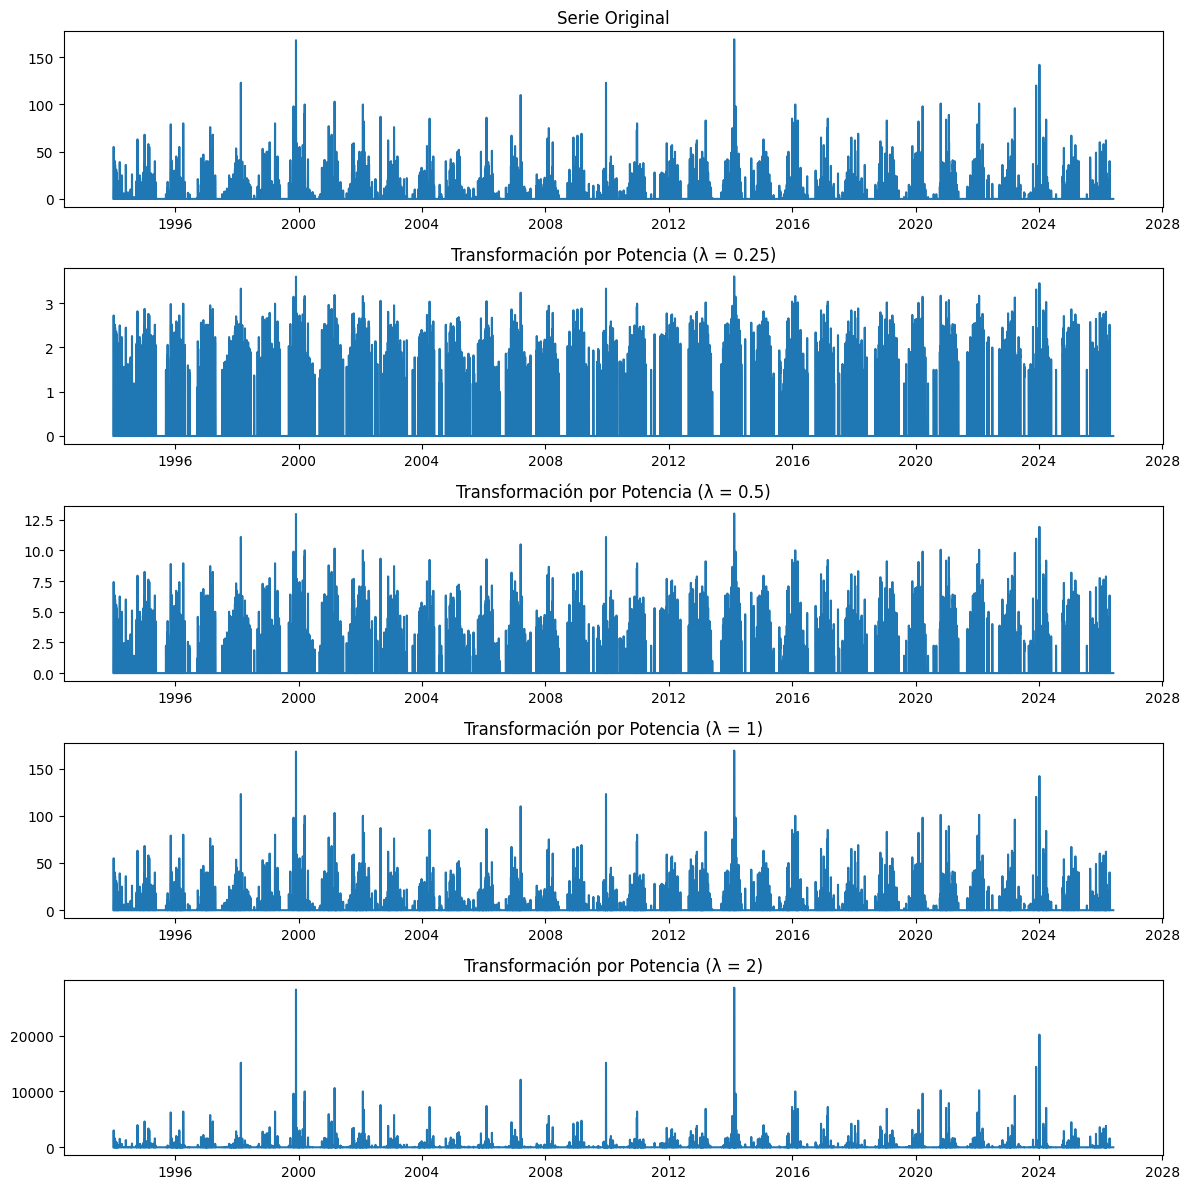

In [ ]:
lambdas = [0.25, 0.5, 1, 2]

fig, axes = plt.subplots(len(lambdas) + 1, 1, figsize=(12, 12))

axes[0].plot(x, y)
axes[0].set_title("Serie Original")

for ax, lambda_ in zip(axes[1:], lambdas):
    ax.plot(x, y ** lambda_) # Acá estaría el cálculo de la serie transformada: elevando el valor de y a lambda_
    ax.set_title(f"Transformación por Potencia (λ = {lambda_})")

plt.tight_layout()
plt.show()

5) Transformación Box-Cox

In [ ]:
from scipy.stats import boxcox

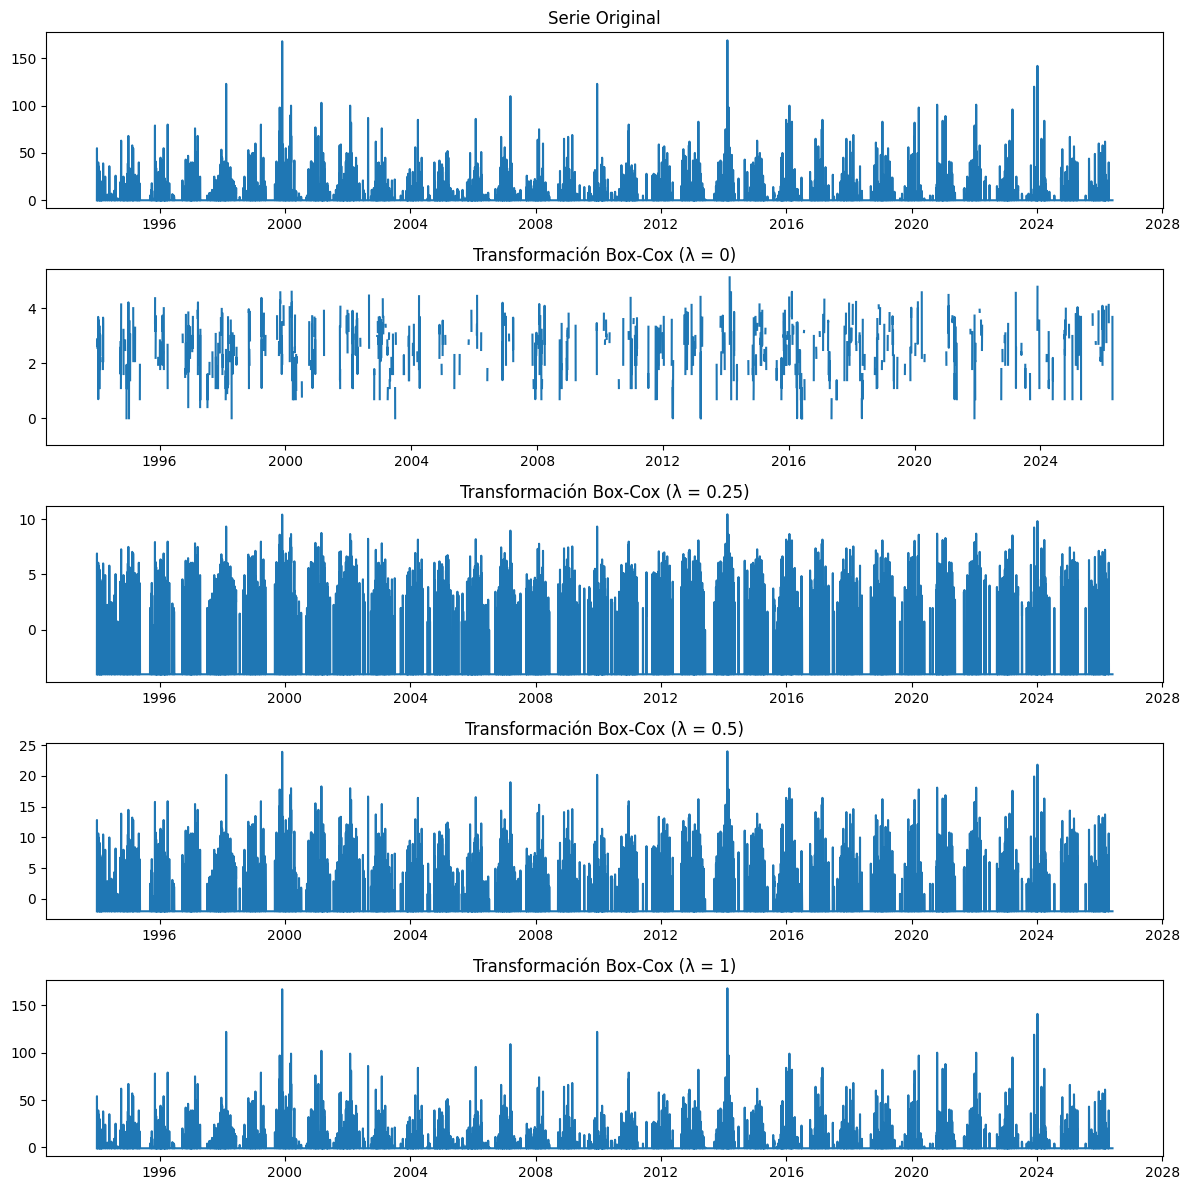

In [ ]:
lambdas = [0, 0.25, 0.5, 1]

fig, axes = plt.subplots( len(lambdas) + 1, 1, figsize=(12, 12))

axes[0].plot(x, y)
axes[0].set_title("Serie Original")

for ax, lambda_ in zip(axes[1:], lambdas):

    y_boxcox = boxcox(y, lmbda = lambda_) # Acá se calcula la serie transformada

    ax.plot(x, y_boxcox)
    ax.set_title(f"Transformación Box-Cox (λ = {lambda_})")

plt.tight_layout()
plt.show()

## Tranformaciones por Diferencia

1) Primera Diferencia $y(t)- y(t-1)$

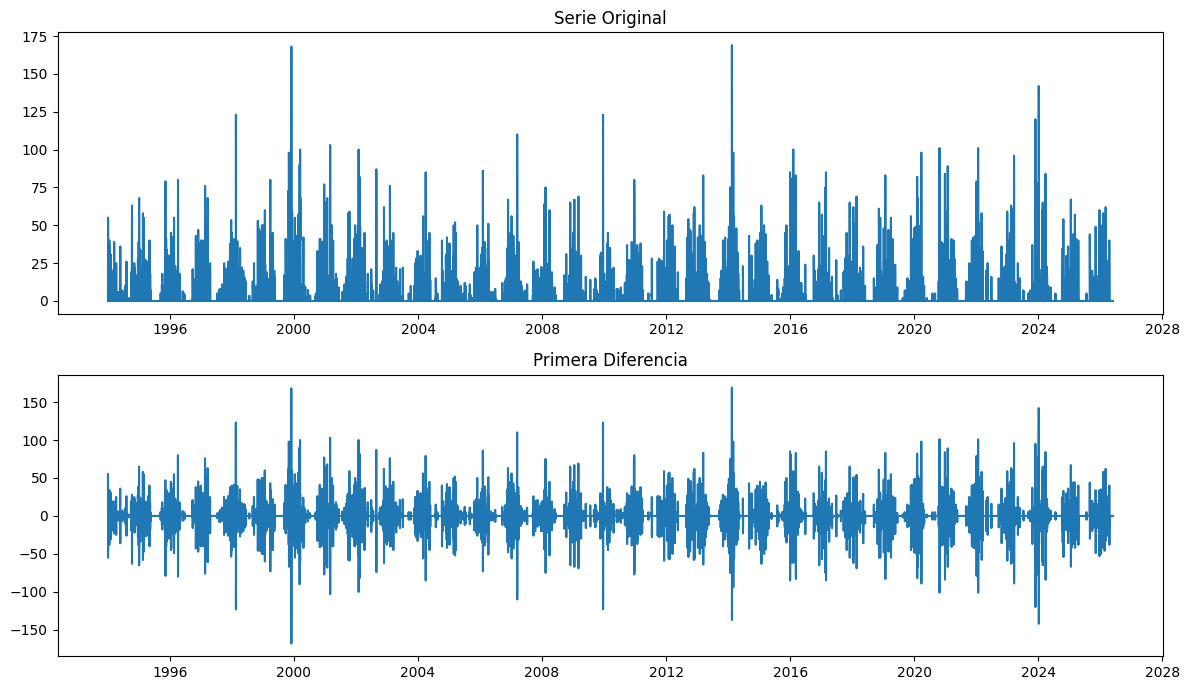

In [ ]:
y_diff = y.diff()

plot_transformation(x, y, y_diff,"Primera Diferencia")

2) Segunda Diferencia

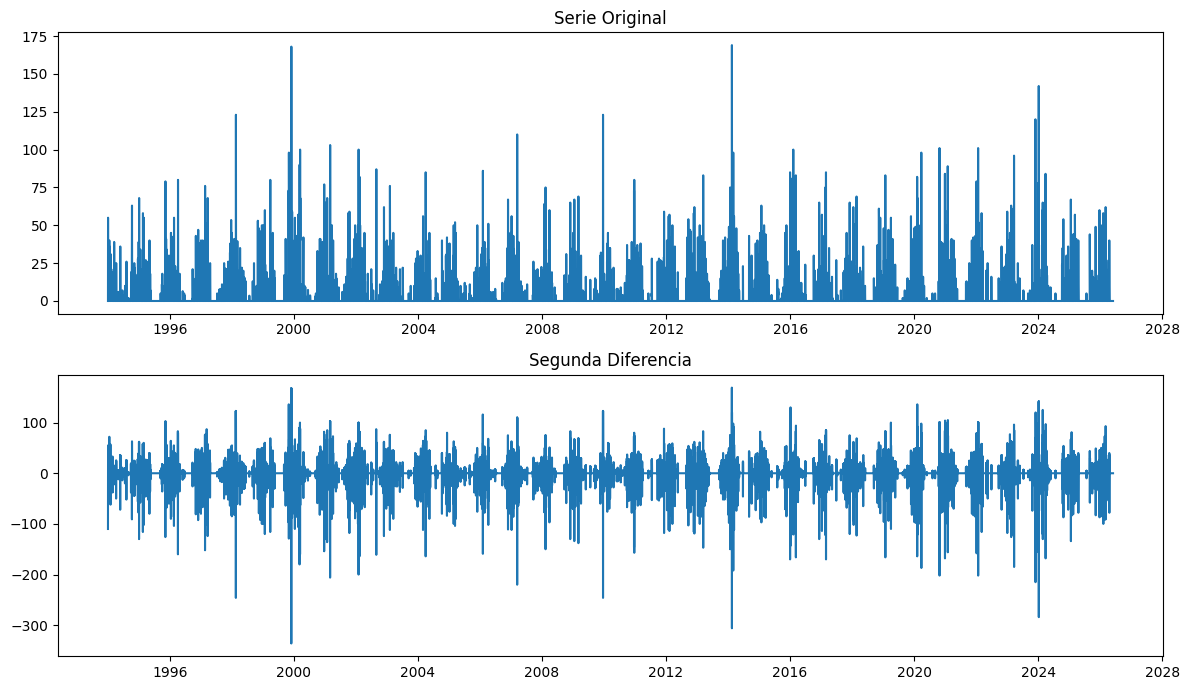

In [ ]:
y_diff2 = y.diff().diff()

plot_transformation(x, y, y_diff2,"Segunda Diferencia")

3) Diferencia Estacional

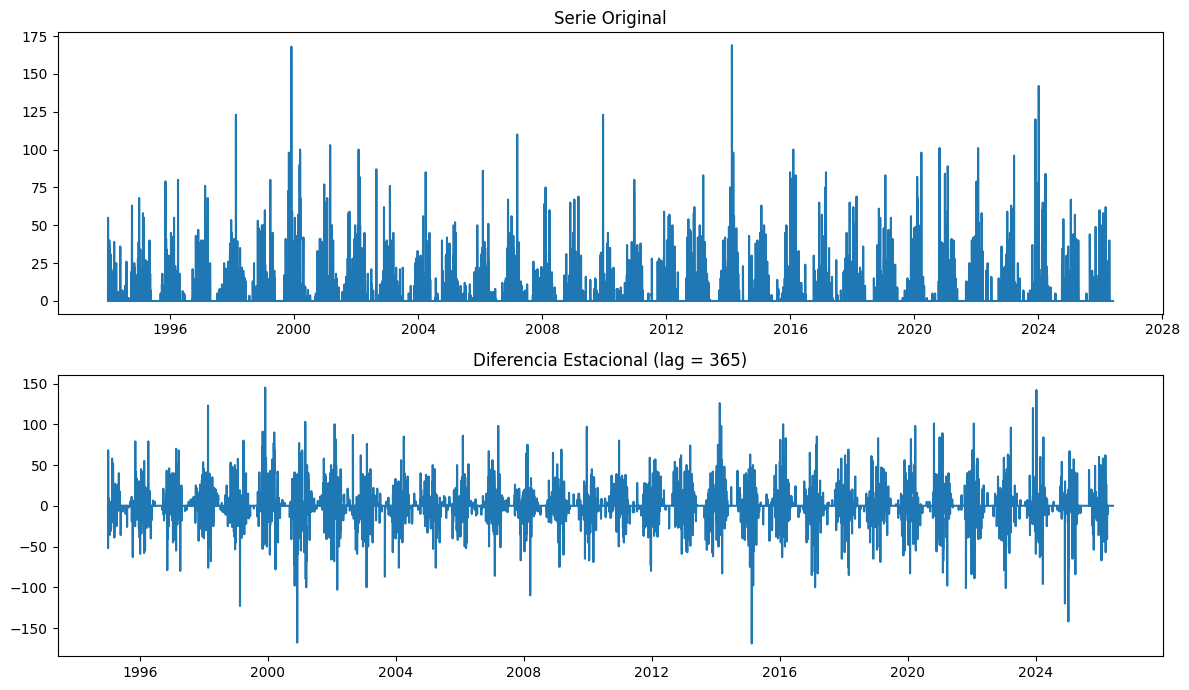

In [ ]:
y_seasonal = y.diff(365)

plot_transformation(x, y, y_seasonal,"Diferencia Estacional (lag = 365)")

4) Combinación de Diferencias:

Estacional + Primera Diferencia

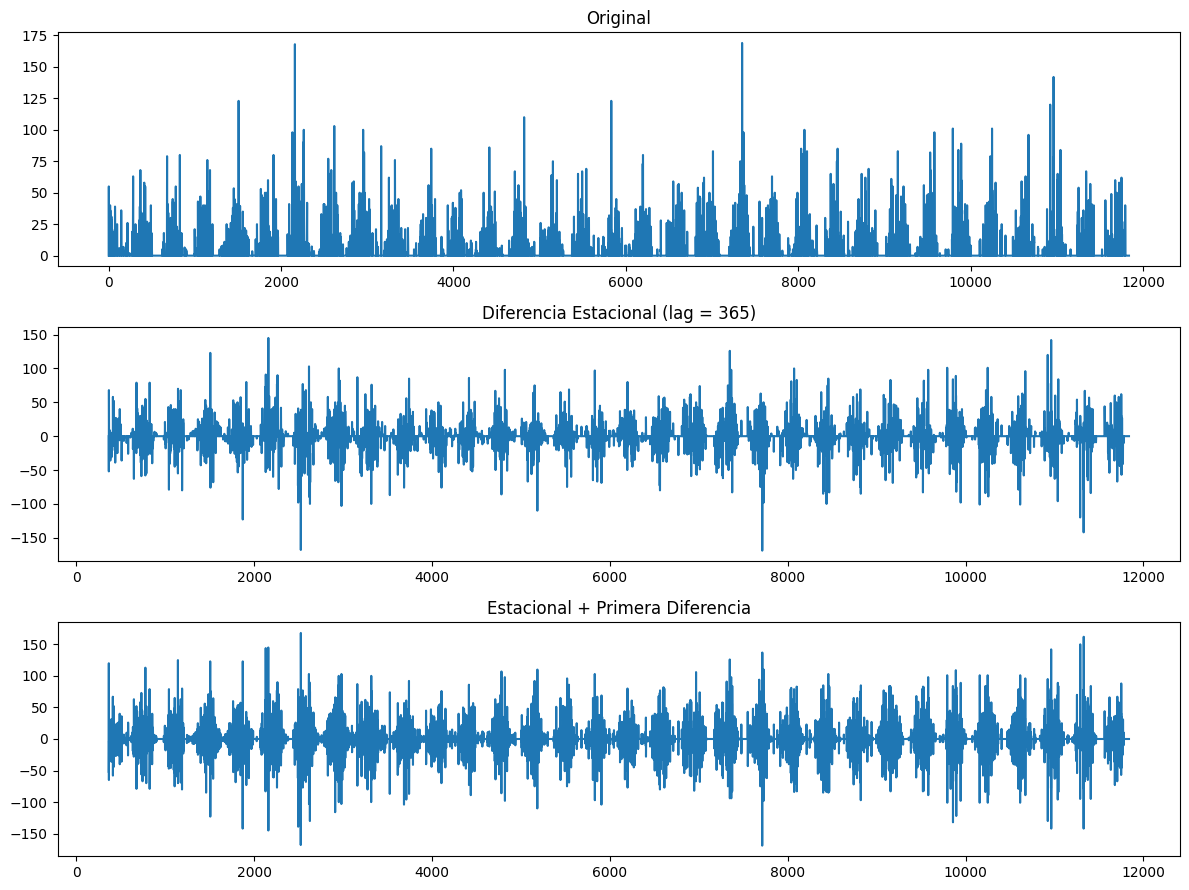

In [ ]:
y_diff_seasonal = y.diff().diff(365)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(y)
axes[0].set_title("Original")

axes[1].plot(y_seasonal)
axes[1].set_title("Diferencia Estacional (lag = 365)")

axes[2].plot(y_diff_seasonal)
axes[2].set_title("Estacional + Primera Diferencia")

plt.tight_layout()
plt.show()